In [64]:
import subprocess
import sys
import os
import time
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from tqdm import tqdm

In [83]:
cpp_executable = "./maingen"  # путь к скомпилированной C++ программе
output_file = "result.txt"  # файл, в который C++ программа пишет результат
reps = 1000;
N = 100000;
delta = 0.1;
distrib = 0; # 0 - uni, 1 - exp, 2 - norm
click_size = 3;

input_args = list(map(str, [N, delta, reps, click_size, distrib]))
command = [cpp_executable] + input_args

In [84]:
process = subprocess.Popen(
    command,
    text=True,
    stdout=subprocess.PIPE
)
with tqdm(total=100, unit="%") as pbar:
    while True:
        line = process.stdout.readline()
        if not line:
            break
        try:
            progress_str = line.split("Progress:")[0].strip()
            progress_value = float(progress_str)
            pbar.update(progress_value - pbar.n) # Update by the difference
        except ValueError:
            pass

100%|█████████████████████████████████████████████████████████████████████████| 100.0/100 [00:22<00:00,  4.40%/s]


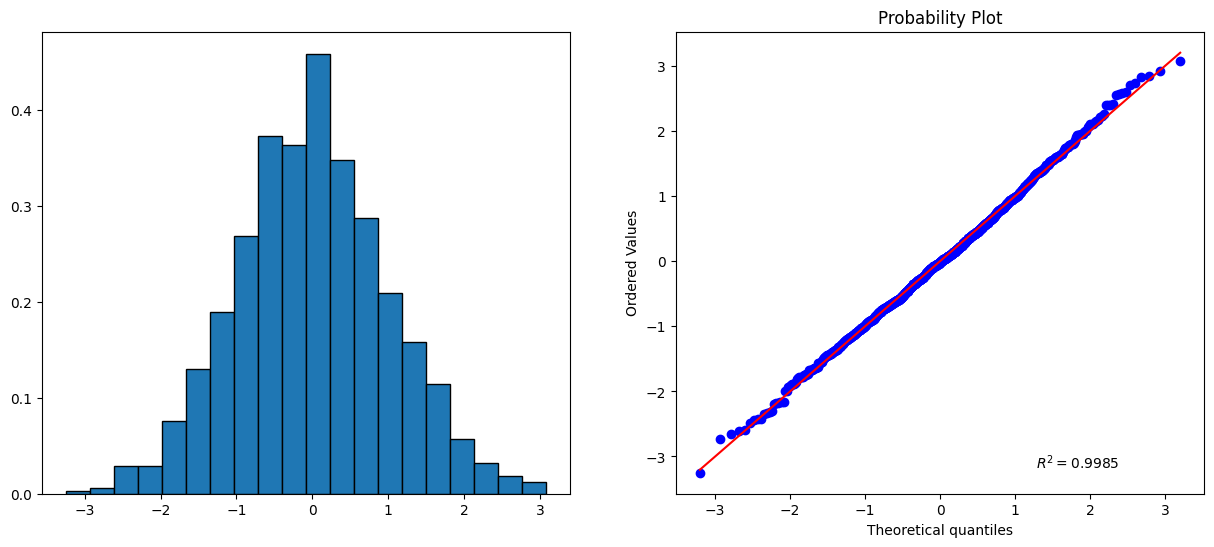

In [79]:
with open(output_file, 'r', encoding='utf-8') as f:
    result = f.read()
result = list(map(float, result.split()))

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

freq, edges = np.histogram(result, bins=20, density=True)
ax[0].bar(edges[:-1], freq, width=np.diff(edges), edgecolor="black", align="edge")
#plt.show()

result = np.asarray(result)
ax[1] = stats.probplot(result, rvalue=True, plot=ax[1])
